# Visualisation des donnees GMM

Ce notebook genere un prior GMM 2D et le posterior associe a une observation lineaire bruitee, puis les visualise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.create_gmm_data import generate_gmm_data


In [2]:
cfg = {
    'seed': 7,
    'n_prior': 4000,
    'n_posterior': 4000,
    'means': np.asarray([[0.3, 0.3], [1.75, -0.25], [0.25, 1.5]], dtype=np.float64),
    'cov_scalar': 0.0625,
    'h': np.asarray([1.5, 1.5], dtype=np.float64),
    'sigma_n': 0.25,
    'y_clean': 1.0,
}

data = generate_gmm_data(**cfg)

print('Observation')
print(f"y_clean    = {data['y_clean']:.4f}")
print(f"y_observed = {data['y_observed']:.4f}")
print(f"sigma_n    = {data['sigma_n']:.4f}")
print('\nPoids posterior des composantes:')
print(np.round(data['post_weights'], 4))

Observation
y_clean    = 1.0000
y_observed = 1.2545
sigma_n    = 0.2500

Poids posterior des composantes:
[0.7341 0.2085 0.0574]


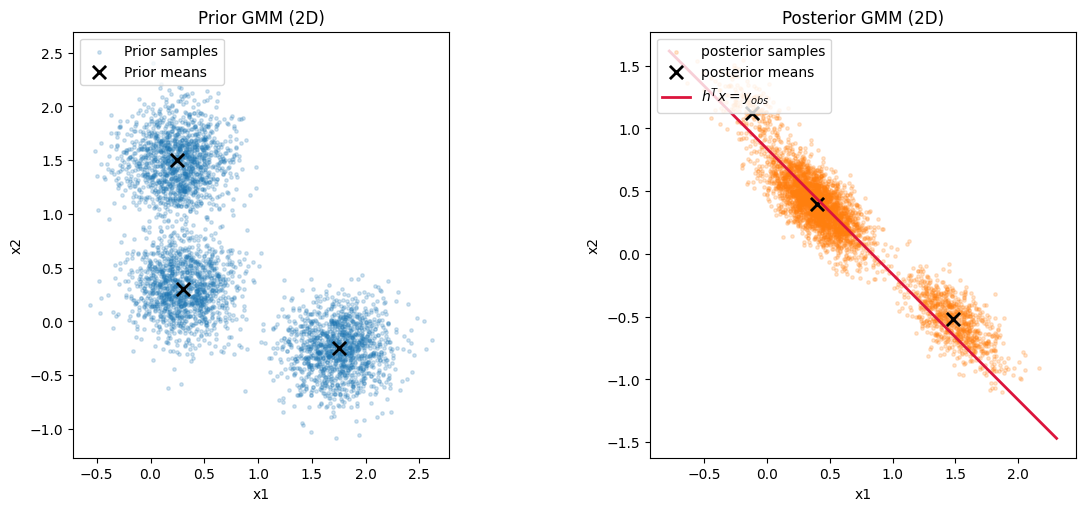

In [3]:
prior = data['prior_samples']
post = data['posterior_samples']
means = data['means']
post_means = data['post_means']
h = data['h']
y_obs = data['y_observed']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Prior
ax = axes[0]
ax.scatter(prior[:, 0], prior[:, 1], s=6, alpha=0.20, color='#1f77b4', label='Prior samples')
ax.scatter(means[:, 0], means[:, 1], s=90, marker='x', color='black', linewidths=2, label='Prior means')
ax.set_title('Prior GMM (2D)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left')

# Posterior
ax = axes[1]
ax.scatter(post[:, 0], post[:, 1], s=6, alpha=0.20, color='#ff7f0e', label='posterior samples')
ax.scatter(post_means[:, 0], post_means[:, 1], s=90, marker='x', color='black', linewidths=2, label='posterior means')

# Droite de mesure: h^T x = y
xlim = ax.get_xlim()
xx = np.linspace(xlim[0], xlim[1], 200)
if abs(h[1]) > 1e-10:
    yy = (y_obs - h[0] * xx) / h[1]
    ax.plot(xx, yy, color='crimson', lw=2, label=r"$h^T x = y_{obs}$")

ax.set_title('Posterior GMM (2D)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left')

plt.show()

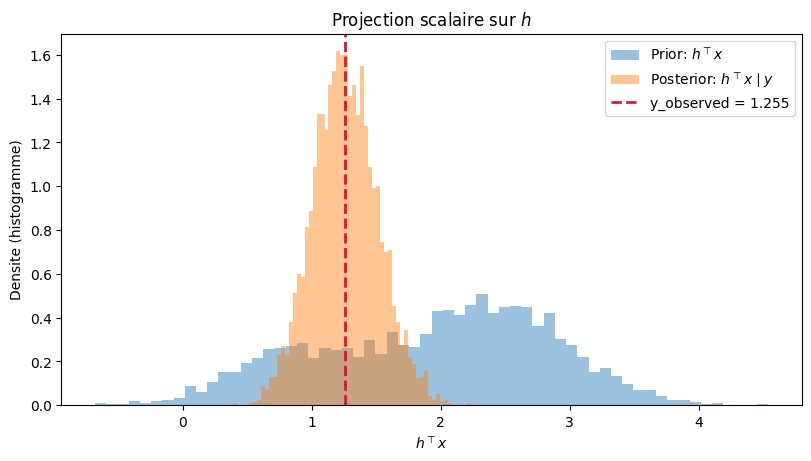

In [4]:
prior_proj = prior @ h
post_proj = post @ h

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.hist(prior_proj, bins=60, density=True, alpha=0.45, color='#1f77b4', label=r'Prior: $h^\top x$')
ax.hist(post_proj, bins=60, density=True, alpha=0.45, color='#ff7f0e', label=r'Posterior: $h^\top x \mid y$')
ax.axvline(y_obs, color='crimson', lw=2, linestyle='--', label=f'y_observed = {y_obs:.3f}')
ax.set_title(r'Projection scalaire sur $h$')
ax.set_xlabel(r'$h^\top x$')
ax.set_ylabel('Densite (histogramme)')
ax.legend()
plt.show()

## Entrainement d'un modele de Flow Matching

Cette section entraine un modele 2D sur les echantillons du posterior, puis sauvegarde le checkpoint dans `results/models_gmm`.

In [5]:
import torch

from scripts.train_gmm_flow_matching import train_flow_matching_gmm
from scripts.gmm_flow_model import TimeConditionedMLP, sample_with_euler


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


In [6]:
cfg

{'seed': 7,
 'n_prior': 4000,
 'n_posterior': 4000,
 'means': array([[ 0.3 ,  0.3 ],
        [ 1.75, -0.25],
        [ 0.25,  1.5 ]]),
 'cov_scalar': 0.0625,
 'h': array([1.5, 1.5]),
 'sigma_n': 0.25,
 'y_clean': 1.0}

In [7]:
train_result = train_flow_matching_gmm(
    data=data,
    output_dir='results/models_gmm',
    batch_size=256,
    epochs=300,
    lr=1e-3,
    hidden_dim=128,
    depth=3,
    device=DEVICE,
    log_every=25,
    **cfg,
)

summary = train_result['summary']
summary

epoch=0000 loss=1.243926
epoch=0025 loss=0.622434
epoch=0050 loss=0.632425
epoch=0075 loss=0.624662
epoch=0100 loss=0.617741
epoch=0125 loss=0.594744
epoch=0150 loss=0.607159
epoch=0175 loss=0.625115
epoch=0200 loss=0.625433
epoch=0225 loss=0.593500
epoch=0250 loss=0.620877
epoch=0275 loss=0.618693
epoch=0299 loss=0.578625


{'seed': 7,
 'epochs': 300,
 'batch_size': 256,
 'lr': 0.001,
 'hidden_dim': 128,
 'depth': 3,
 'device': 'cpu',
 'final_loss': 0.5786254942417145,
 'model_path': 'C:\\Users\\titou\\OneDrive\\Bureau\\mva\\gen_images\\flower\\flowerf\\results\\models_gmm\\model_final.pt',
 'losses_path': 'C:\\Users\\titou\\OneDrive\\Bureau\\mva\\gen_images\\flower\\flowerf\\results\\models_gmm\\losses.npy',
 'y_observed': 1.2545243241880377,
 'post_weights': [0.7341046598970232, 0.2085244343489763, 0.05737090575400045],
 'generated_samples_path': 'C:\\Users\\titou\\OneDrive\\Bureau\\mva\\gen_images\\flower\\flowerf\\results\\models_gmm\\generated_samples.npy'}

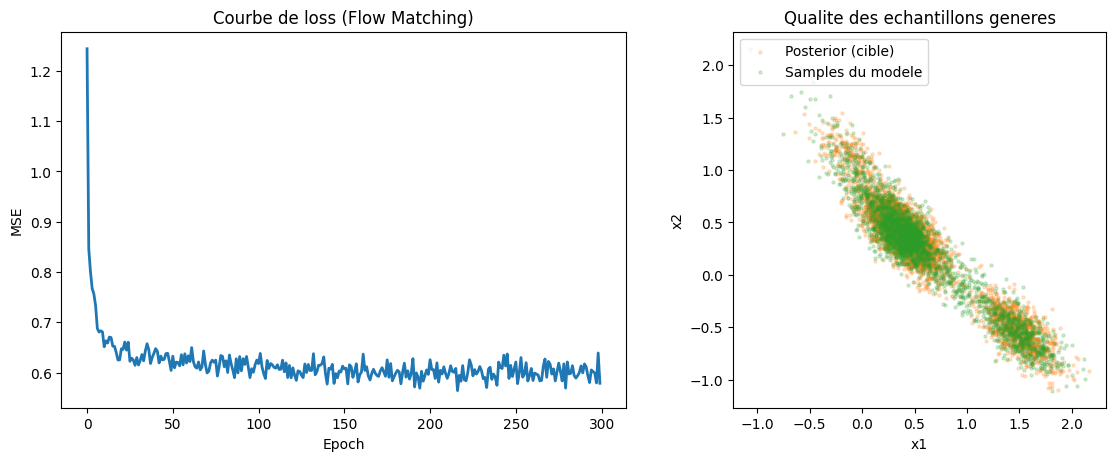

In [8]:
losses = np.asarray(train_result['losses'])
posterior_samples = train_result['data']['posterior_samples']
generated_samples = train_result['generated_samples']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(losses, lw=2, color='#1f77b4')
axes[0].set_title('Courbe de loss (Flow Matching)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')

axes[1].scatter(posterior_samples[:, 0], posterior_samples[:, 1], s=5, alpha=0.20, label='Posterior (cible)', color='#ff7f0e')
axes[1].scatter(generated_samples[:, 0], generated_samples[:, 1], s=5, alpha=0.20, label='Samples du modele', color='#2ca02c')
axes[1].set_title('Qualite des echantillons generes')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].legend(loc='upper left')
axes[1].set_aspect('equal', adjustable='box')

plt.show()

## Flower style v2 (comme toy_gmm_2d_experiments_v2)

Cette section reproduit le schema du notebook `toy_gmm_2d_experiments_v2.ipynb`:
1. vues globales des trajectoires
2. vue step-by-step (Step 1 / Step 2 / Step 3)
3. rerun optionnel pour plusieurs `delta t` (via plusieurs `N`)


In [9]:
from pathlib import Path
import json

from scripts.flower_plotting import plot_snapshots, plot_step_by_step
from scripts.flower_steps import run_flower_step_by_step_2d, run_flower_trajectories_2d


In [10]:
# Main run (same spirit as toy_gmm_2d_experiments_v2)
fm_model = train_result['model'].eval()
device_obj = next(fm_model.parameters()).device

true_samples = torch.tensor(train_result['data']['posterior_samples'], dtype=torch.float32)
h_vec = torch.tensor(train_result['data']['h'], dtype=torch.float32, device=device_obj)
y_value = float(train_result['data']['y_observed'])
sigma_n_value = float(train_result['data']['sigma_n'])

cfg_v2 = {
    'N': 200,
    'n_traj': 5000,
    'n_step_details': 2000,
    'save_every': 40,
    'gamma': 1,
    'observe_steps': [20, 100, 200],
    'seed': 7,
}

torch.manual_seed(cfg_v2['seed'])
np.random.seed(cfg_v2['seed'])

snapshots = run_flower_trajectories_2d(
    model=fm_model,
    n_traj=int(cfg_v2['n_traj']),
    N=int(cfg_v2['N']),
    h_vec=h_vec,
    y_value=y_value,
    sigma_n=sigma_n_value,
    gamma=int(cfg_v2['gamma']),
    save_every=int(cfg_v2['save_every']),
)

step_details = run_flower_step_by_step_2d(
    model=fm_model,
    n_traj=int(cfg_v2['n_step_details']),
    N=int(cfg_v2['N']),
    h_vec=h_vec,
    y_value=y_value,
    sigma_n=sigma_n_value,
    gamma=int(cfg_v2['gamma']),
    observe_steps=[int(s) for s in cfg_v2['observe_steps']],
)

final_samples = snapshots[max(snapshots.keys())]
print('dt =', 1.0 / float(cfg_v2['N']))
print('observe_steps =', sorted(step_details.keys()))


dt = 0.005
observe_steps = [20, 100, 200]


In [11]:
# Save artifacts + figures
OUT_DIR = Path('results/models_gmm/notebook_v2_style')
(OUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'samples').mkdir(parents=True, exist_ok=True)

plot_snapshots(
    snapshots=snapshots,
    true_samples=true_samples,
    h_vec=h_vec.detach().cpu(),
    y_value=y_value,
    out_file=OUT_DIR / 'figures' / 'flower_trajectories.png',
)

plot_step_by_step(
    step_details=step_details,
    true_samples=true_samples,
    h_vec=h_vec.detach().cpu(),
    y_value=y_value,
    out_file=OUT_DIR / 'figures' / 'flower_step_by_step.png',
)

np.savez(
    OUT_DIR / 'samples' / 'posterior_vs_flower_final.npz',
    true=true_samples.numpy(),
    flower_final=final_samples.numpy(),
)

np.savez(
    OUT_DIR / 'samples' / 'step_by_step_samples.npz',
    **{f"step_{k}_{name}": tensor.numpy() for k, d in step_details.items() for name, tensor in d.items() if name != 't'},
)

(OUT_DIR / 'run_config.json').write_text(json.dumps(cfg_v2, indent=2), encoding='utf-8')

print('saved:', OUT_DIR / 'figures' / 'flower_trajectories.png')
print('saved:', OUT_DIR / 'figures' / 'flower_step_by_step.png')


saved: results\models_gmm\notebook_v2_style\figures\flower_trajectories.png
saved: results\models_gmm\notebook_v2_style\figures\flower_step_by_step.png


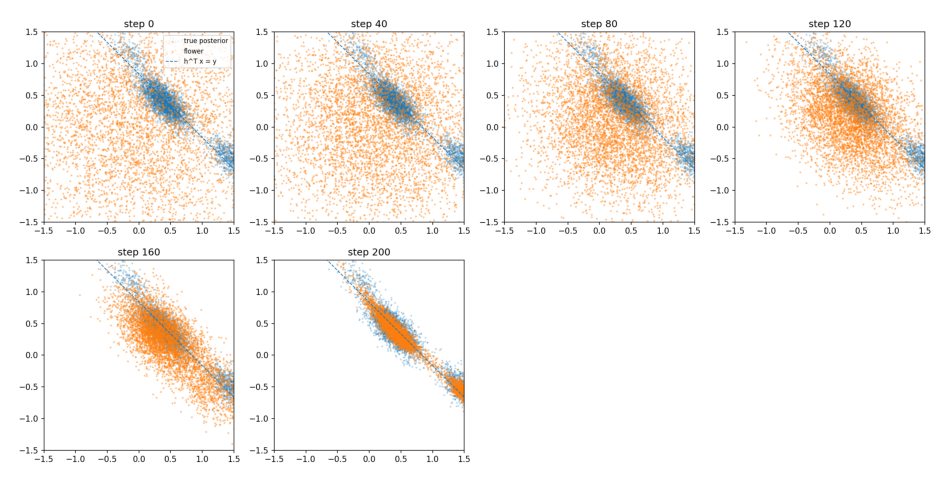

In [12]:
# Display global trajectory view
img = plt.imread(str(OUT_DIR / 'figures' / 'flower_trajectories.png'))
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()


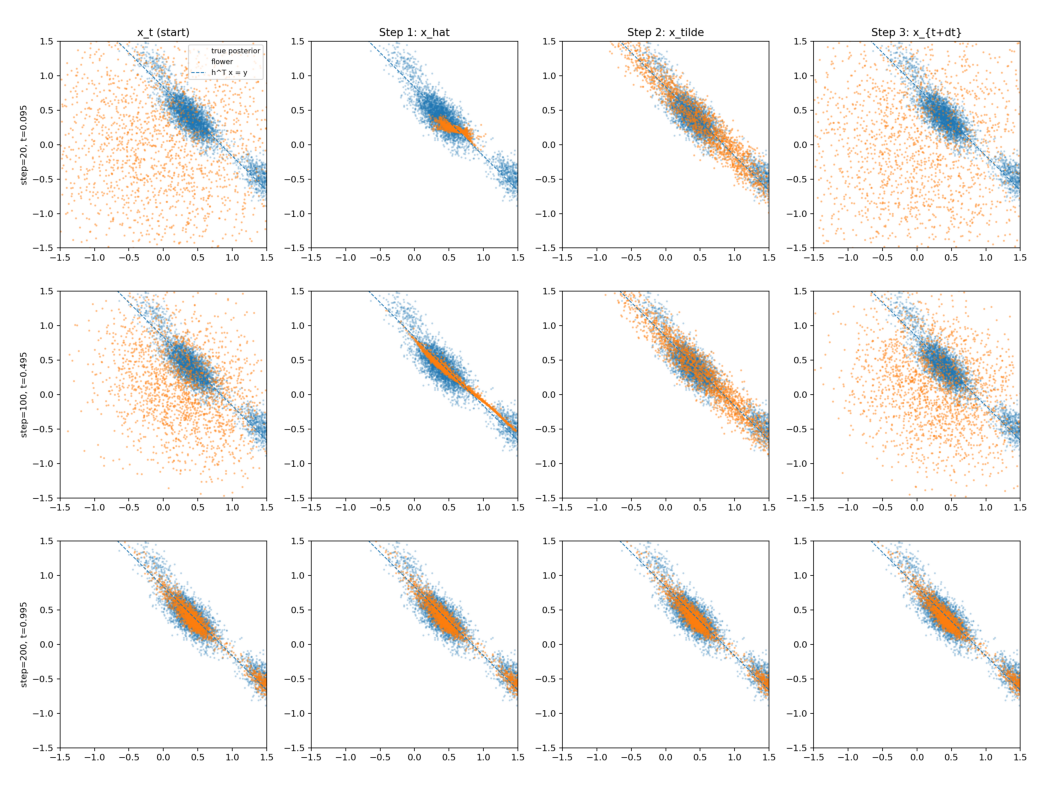

In [13]:
# Display step-by-step view (Step 1 / Step 2 / Step 3)
img2 = plt.imread(str(OUT_DIR / 'figures' / 'flower_step_by_step.png'))
plt.figure(figsize=(16, 10))
plt.imshow(img2)
plt.axis('off')
plt.show()


dt_target=0.0200, dt_eff=0.0200, N=50, saved=flower_step_by_step_dt_0.0200.png


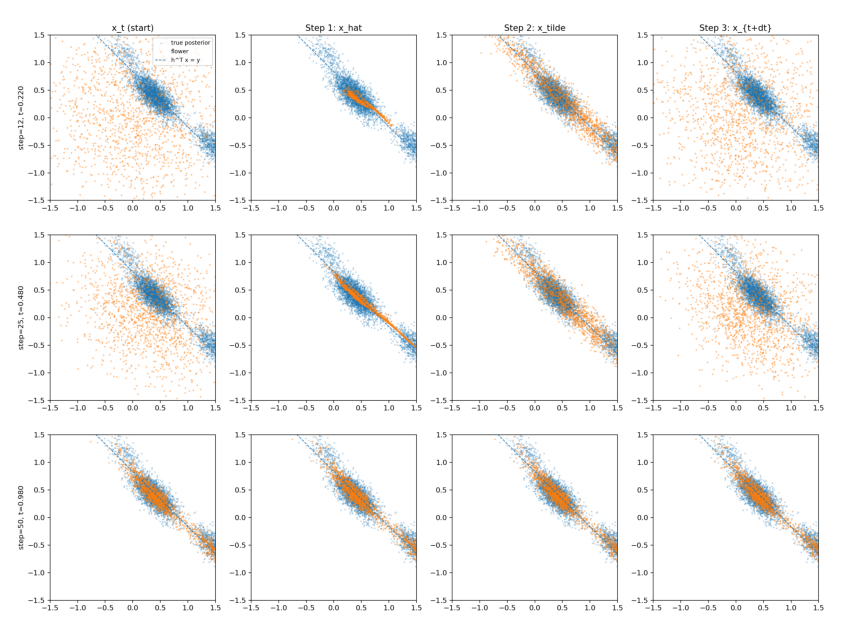

dt_target=0.0100, dt_eff=0.0100, N=100, saved=flower_step_by_step_dt_0.0100.png


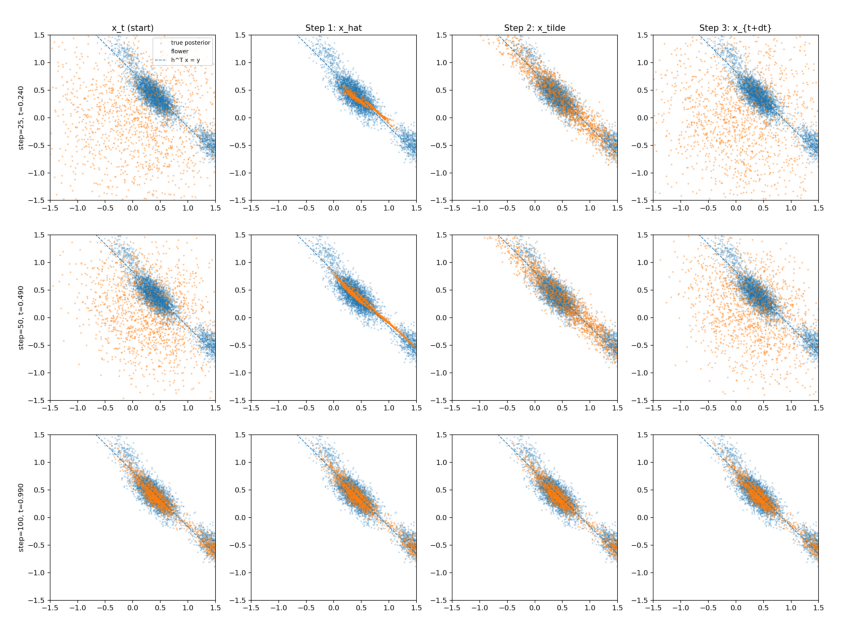

dt_target=0.0050, dt_eff=0.0050, N=200, saved=flower_step_by_step_dt_0.0050.png


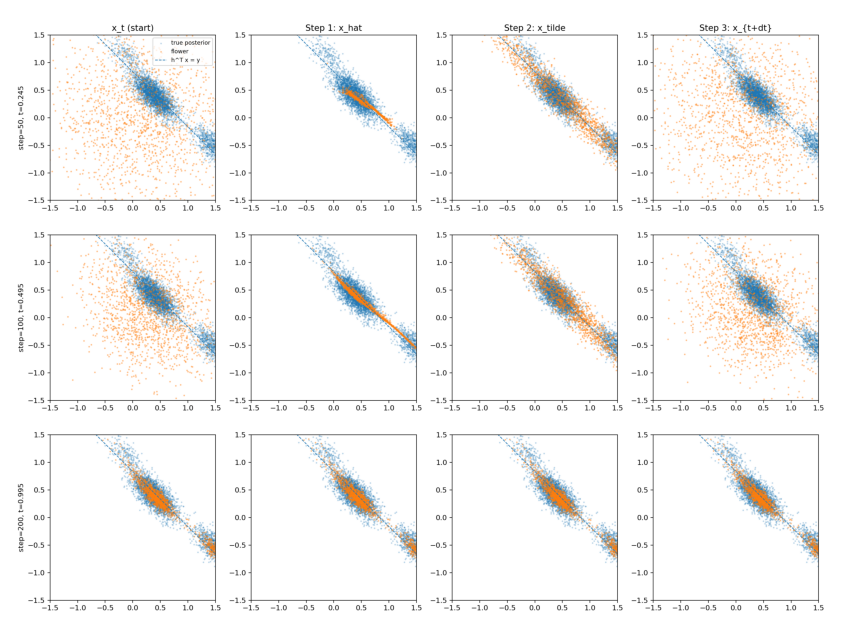

In [14]:
# Optional: same step-by-step for multiple delta t (different N)
DT_LIST = [0.02, 0.01, 0.005]
OBS_FRAC = [0.25, 0.5, 1.0]

for dt_target in DT_LIST:
    N_local = max(2, int(round(1.0 / dt_target)))
    dt_eff = 1.0 / float(N_local)
    observe_local = sorted(set(max(1, min(N_local, int(round(f * N_local)))) for f in OBS_FRAC))

    torch.manual_seed(cfg_v2['seed'])
    np.random.seed(cfg_v2['seed'])

    details_local = run_flower_step_by_step_2d(
        model=fm_model,
        n_traj=1500,
        N=N_local,
        h_vec=h_vec,
        y_value=y_value,
        sigma_n=sigma_n_value,
        gamma=int(cfg_v2['gamma']),
        observe_steps=observe_local,
    )

    out_file = OUT_DIR / 'figures' / f'flower_step_by_step_dt_{dt_eff:.4f}.png'
    plot_step_by_step(
        step_details=details_local,
        true_samples=true_samples,
        h_vec=h_vec.detach().cpu(),
        y_value=y_value,
        out_file=out_file,
    )

    print(f'dt_target={dt_target:.4f}, dt_eff={dt_eff:.4f}, N={N_local}, saved={out_file.name}')

    img_dt = plt.imread(str(out_file))
    plt.figure(figsize=(16, 8))
    plt.imshow(img_dt)
    plt.axis('off')
    plt.show()
